# Assign GeoCoords

This notebook demonstrates how to work with geocoordinates (longitude and latitude) instead of radar-centric x and y coordinates.

In [1]:
import cmweather  # noqa: F401
import matplotlib.pyplot as plt
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

## Define Functions

In [2]:
def get_geocoords(ds):
    """
    Converts Cartesian coordinates (x, y, z) in a radar dataset to geographic
    coordinates (longitude, latitude, altitude) using CRS transformation.

    Parameters
    ----------
    ds : xarray.Dataset
        Radar dataset with Cartesian coordinates.

    Returns
    -------
    xarray.Dataset
        Dataset with added 'lon', 'lat', and 'alt' coordinates and their attributes.
    """
    from pyproj import CRS, Transformer

    # Convert the dataset to georeferenced coordinates
    ds = ds.xradar.georeference()
    # Define source and target coordinate reference systems (CRS)
    src_crs = ds.xradar.get_crs()
    trg_crs = CRS.from_user_input(4326)  # EPSG:4326 (WGS 84)
    # Create a transformer for coordinate conversion
    transformer = Transformer.from_crs(src_crs, trg_crs)
    # Transform x, y, z coordinates to latitude, longitude, and altitude
    trg_y, trg_x, trg_z = transformer.transform(ds.x, ds.y, ds.z)
    # Assign new coordinates with appropriate attributes
    ds = ds.assign_coords(
        {
            "lon": (ds.x.dims, trg_x, xd.model.get_longitude_attrs()),
            "lat": (ds.y.dims, trg_y, xd.model.get_latitude_attrs()),
            "alt": (ds.z.dims, trg_z, xd.model.get_altitude_attrs()),
        }
    )
    return ds


def fix_sitecoords(ds):
    coords = ["longitude", "latitude", "altitude", "altitude_agl"]
    for coord in coords:
        # Compute median excluding NaN
        data = ds[coord].median(skipna=True).item()
        attrs = ds[coord].attrs if coord in ds else {}
        ds = ds.assign_coords({coord: xr.DataArray(data=data, attrs=attrs)})
    return ds

## Load Data

In [3]:
file1 = DATASETS.fetch("cfrad.20080604_002217_000_SPOL_v36_SUR.nc")
file2 = DATASETS.fetch("cfrad.20211011_201557.188_to_20211011_201617.720_DOW8_PPI.nc")

## Example #1

In [4]:
dtree1 = xd.io.open_cfradial1_datatree(file1)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [5]:
dtree1 = dtree1.xradar.georeference()

In [6]:
display(dtree1["sweep_0"].ds)

<xarray.DatasetView> Size: 15MB
Dimensions:                    (azimuth: 483, range: 996)
Coordinates:
  * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
    elevation                  (azimuth) float32 2kB 0.5164 0.5219 ... 0.5219
    time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:15:...
  * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
    latitude                   float64 8B 22.53
    longitude                  float64 8B 120.4
    altitude                   float64 8B 45.0
    crs_wkt                    int64 8B 0
    x                          (azimuth, range) float64 4MB 0.0 ... -1.955e+03
    y                          (azimuth, range) float64 4MB 150.0 ... 1.493e+05
    z                          (azimuth, range) float64 4MB 46.35 ... 2.718e+03
Data variables: (12/18)
    sweep_number               int32 4B ...
    sweep_mode                 <U20 80B 'azimuth_surveillance'
    prt_mode                   |S32 32B ...
    follow_mode                |S32 32B ...
    sweep_fixed_angle          float32 4B ...
    pulse_width                (azimuth) float32 2kB ...
    ...                         ...
    r_calib_index              (azimuth) int8 483B ...
    measured_transmit_power_h  (azimuth) float32 2kB ...
    measured_transmit_power_v  (azimuth) float32 2kB ...
    scan_rate                  (azimuth) float32 2kB ...
    DBZ                        (azimuth, range) float32 2MB ...
    VR                         (azimuth, range) float32 2MB ...

## Assign lat, lon, and alt

In [7]:
dtree1 = dtree1.xradar.map_over_sweeps(get_geocoords)

In [8]:
display(dtree1["sweep_0"].ds)

<xarray.DatasetView> Size: 27MB
Dimensions:                    (azimuth: 483, range: 996)
Coordinates: (12/14)
  * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
    elevation                  (azimuth) float32 2kB 0.5164 0.5219 ... 0.5219
    time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:15:...
  * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
    latitude                   float64 8B 22.53
    longitude                  float64 8B 120.4
    ...                         ...
    x                          (azimuth, range) float64 4MB 0.0 ... -1.955e+03
    y                          (azimuth, range) float64 4MB 150.0 ... 1.493e+05
    z                          (azimuth, range) float64 4MB 46.35 ... 2.718e+03
    lon                        (azimuth, range) float64 4MB 120.4 ... 120.4
    lat                        (azimuth, range) float64 4MB 22.53 ... 23.88
    alt                        (azimuth, range) float64 4MB 46.35 ... 2.718e+03
Data variables: (12/18)
    sweep_number               int32 4B ...
    sweep_mode                 <U20 80B 'azimuth_surveillance'
    prt_mode                   |S32 32B ...
    follow_mode                |S32 32B ...
    sweep_fixed_angle          float32 4B ...
    pulse_width                (azimuth) float32 2kB ...
    ...                         ...
    r_calib_index              (azimuth) int8 483B ...
    measured_transmit_power_h  (azimuth) float32 2kB ...
    measured_transmit_power_v  (azimuth) float32 2kB ...
    scan_rate                  (azimuth) float32 2kB ...
    DBZ                        (azimuth, range) float32 2MB ...
    VR                         (azimuth, range) float32 2MB ...

In [9]:
ds = dtree1["sweep_0"].to_dataset()

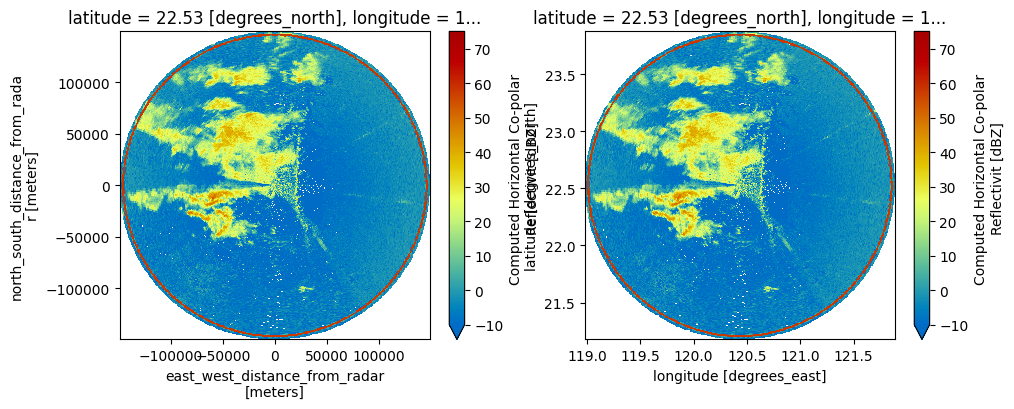

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ds["DBZ"].plot(x="x", y="y", vmin=-10, vmax=75, cmap="HomeyerRainbow", ax=ax[0])

ds["DBZ"].plot(x="lon", y="lat", vmin=-10, vmax=75, cmap="HomeyerRainbow", ax=ax[1])
plt.show()

## Example #2

In [11]:
dtree2 = xd.io.open_cfradial1_datatree(file2)

In [12]:
try:
    dtree2 = dtree2.xradar.georeference()
except Exception:
    print("Georeferencing failed!")

Georeferencing failed!


In [13]:
print("Longitude", dtree2["sweep_0"]["longitude"].shape)
print("Latitude", dtree2["sweep_0"]["latitude"].shape)

Longitude (731,)
Latitude (731,)


<div class="alert alert-info">
    <p style="font-weight:bold; margin:0;">Important Note:</p>
    <p>
        This radar data is from a mobile research radar called <b>Doppler on Wheels (DOW)</b>, and its site coordinates (latitude, longitude) 
        often vary slightly during operation, as can be seen from the shape (<code>(731)</code>) of the data in the above cell, while we expect it to 
        be of unity shapes or empty, i.e., <code>(1)</code> or <code>()</code>. As a result, multiple site coordinate values can exist, creating a challenge for assigning 
        consistent <code>x, y, z</code> or <code>lat, lon, and alt</code> coordinates using the current georeferencing system in <code>xradar</code>. 
        To address this, a custom function like <code>fix_sitecoords</code> (defined above) can be created, leveraging the <code>map_over_sweeps</code> 
        function to standardize the site coordinates.
    </p>
</div>

## Fix Coords

In [14]:
dtree2 = dtree2.xradar.map_over_sweeps(fix_sitecoords)

In [15]:
dtree2 = dtree2.xradar.map_over_sweeps(get_geocoords)

In [16]:
display(dtree2["sweep_0"].ds)

<xarray.DatasetView> Size: 116MB
Dimensions:                    (azimuth: 731, range: 1984, frequency: 1)
Coordinates: (12/16)
  * frequency                  (frequency) float32 4B 9.45e+09
    altitude_agl               float64 8B nan
  * azimuth                    (azimuth) float32 3kB 0.0 0.5 1.0 ... 359.0 359.5
    elevation                  (azimuth) float32 3kB 0.4395 0.4395 ... 0.4395
    latitude                   float64 8B 40.01
    longitude                  float64 8B -88.33
    ...                         ...
    x                          (azimuth, range) float64 12MB 0.0 ... -1.297e+03
    y                          (azimuth, range) float64 12MB 37.47 ... 1.486e+05
    z                          (azimuth, range) float64 12MB 211.3 ... 2.652e+03
    lon                        (azimuth, range) float64 12MB -88.33 ... -88.35
    lat                        (azimuth, range) float64 12MB 40.02 ... 41.35
    alt                        (azimuth, range) float64 12MB 211.3 ... 2.652e+03
Data variables: (12/30)
    sweep_number               float64 8B ...
    sweep_mode                 <U6 24B 'sector'
    prt_mode                   |S32 32B ...
    follow_mode                |S32 32B ...
    sweep_fixed_angle          float32 4B ...
    ray_start_range            (azimuth) float32 3kB ...
    ...                         ...
    DBMHC                      (azimuth, range) float32 6MB ...
    DBZHC                      (azimuth, range) float32 6MB ...
    VEL                        (azimuth, range) float32 6MB ...
    VS1                        (azimuth, range) float32 6MB ...
    VL1                        (azimuth, range) float32 6MB ...
    WIDTH                      (azimuth, range) float32 6MB ...

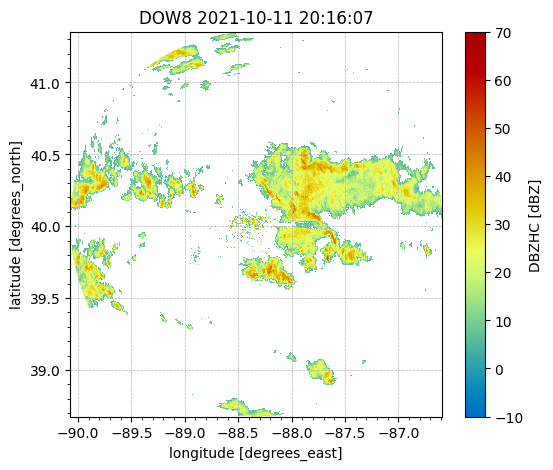

In [17]:
ds = dtree2["sweep_0"].to_dataset()
ref = ds.where(ds.DBZHC >= 5)["DBZHC"]

fig = plt.figure(figsize=(6, 5))
ax = plt.axes()
pl = ref.plot(
    x="lon",
    y="lat",
    vmin=-10,
    vmax=70,
    cmap="HomeyerRainbow",
    ax=ax,
)

ax.minorticks_on()
ax.grid(ls="--", lw=0.5)
ax.set_aspect("auto")
title = (
    dtree2.attrs["instrument_name"]
    + " "
    + str(ds.time.mean().dt.strftime("%Y-%m-%d %H:%M:%S").values)
)
ax.set_title(title)
plt.show()